Plot skewness and Kurtosis of samples of inter-arrival and service distribution based on their moments.

In [10]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from Sampling.Save_Combine_Read_for_CSV_files import Load_Samples_from_file
from Training.Class_training import NN_for_Queue


In [11]:
##### Parameters
n_max = 10           # The highest order of moments
Lmax = 500           # The maximum queue length
m_max = 15           # The maximum order of PH-representation (alpha, T)
input_dim = 2*n_max  # DNN input dimension: arrival n_max + service n_max


In [12]:
def normalize_moments_to_mean_one(moms):
    """
    moms: shape (N, >=4), raw moments m1, m2, m3, m4
    returns: normalized moments with mean = 1
    """
    m1 = moms[:, 0]
    moms_norm = moms.copy()

    # m_k(X / m1) = m_k(X) / m1^k
    for k in range(moms.shape[1]):
        moms_norm[:, k] = moms[:, k] / (m1 ** (k + 1)) # normalize by dividing by (m1 ** (k + 1))

    return moms_norm


In [13]:
def skew_kurt_from_raw_moments(moms):
    """
    moms: shape (N, >=4), raw moments with mean already normalized to 1
    """
    m1, m2, m3, m4 = moms[:,0], moms[:,1], moms[:,2], moms[:,3]

    var = m2 - m1**2
    std = np.sqrt(var)

    mu3 = m3 - 3*m2*m1 + 2*m1**3 # third central moment
    mu4 = m4 - 4*m3*m1 + 6*m2*m1**2 - 3*m1**4 # fourth central moment

    skew = mu3 / std**3 # Skewness
    kurt = mu4 / std**4 # Kurtosis

    return skew, kurt

In [14]:
def summary_table(x, name='skewness'):
    summary = {
        'Count': len(x),
        'Mean': np.mean(x),
        'Std': np.std(x, ddof=1),
        'Min': np.min(x),
        '10%': np.quantile(x, 0.10),
        '25%': np.quantile(x, 0.25),
        'Median': np.quantile(x, 0.50),
        '75%': np.quantile(x, 0.75),
        '90%': np.quantile(x, 0.90),
        'Max': np.max(x)
    }
    return pd.DataFrame(summary, index=[name])


In [15]:
# function to plot skew and kurt given K and queue_type
def plot_skew_kurt(K, queue_type):

    # load samples
    DNN_net = NN_for_Queue(
        queue_type=queue_type, n_max=n_max, Lmax=Lmax, m_max=m_max, input_dim=input_dim, num_classes=Lmax
    )

    df_all_K = DNN_net.Load_and_Merge_All_Samples_for_K(K) 

    # sample shape
    print("Total samples for K=", K, ":", df_all_K.shape[0])

    # Break samples into Moments, stationary distribution, and rho blocks
    Moments_all, Stationary_all, rho_all = Load_Samples_from_file(n_max, Lmax, df_all_K)
    # convert to float
    Moments_all = Moments_all.astype(float)
    Stationary_all = Stationary_all.astype(float)

    Moments_all_real = np.exp(Moments_all) -1 # transfer back to moments
    Moments_arrival = Moments_all_real[:, :n_max] # obtain arrival monents
    Moments_service = Moments_all_real[:, n_max:] # obtain service moments
    # 1. mean normalization
    mom_arr_n = normalize_moments_to_mean_one(Moments_arrival)
    mom_ser_n = normalize_moments_to_mean_one(Moments_service)
    # 2. skewness & kurtosis
    skew_a, kurt_a = skew_kurt_from_raw_moments(mom_arr_n)
    skew_s, kurt_s = skew_kurt_from_raw_moments(mom_ser_n)  
    plt.figure(figsize=(6,5))
    plt.scatter(skew_a, kurt_a, alpha=0.5, label='Interarrival')
    plt.scatter(skew_s, kurt_s, alpha=0.5, label='Service')
    plt.xlabel('Skewness')
    plt.ylabel('Kurtosis')
    plt.xlim(0,10)
    plt.ylim(0,100)
    plt.title(f'K={K}, Queue Type={queue_type}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Processing K=1, queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 1 : 482270


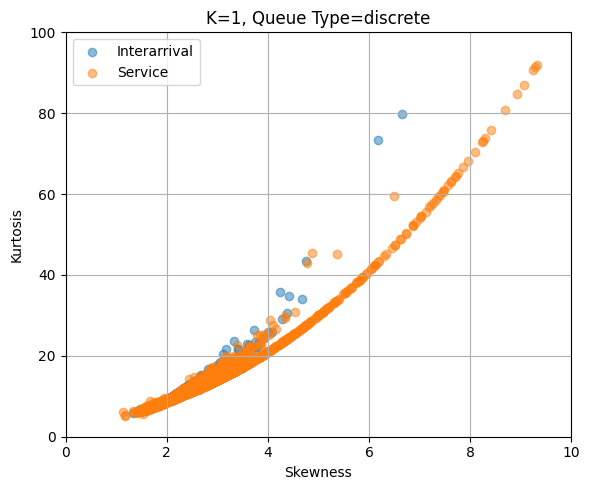

Processing K=1, queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 1 : 530025


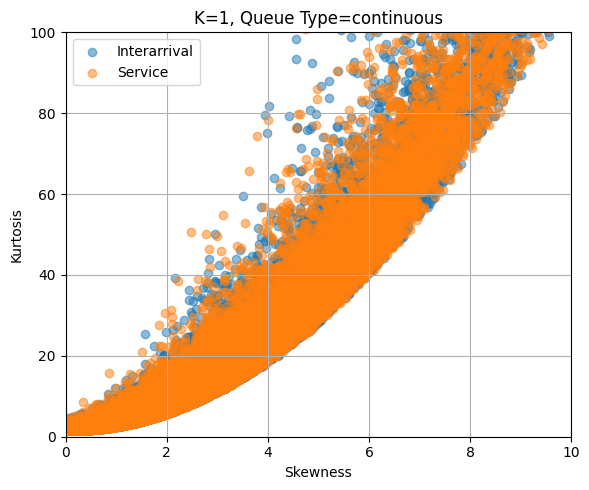

Processing K=2, queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 2 : 89216


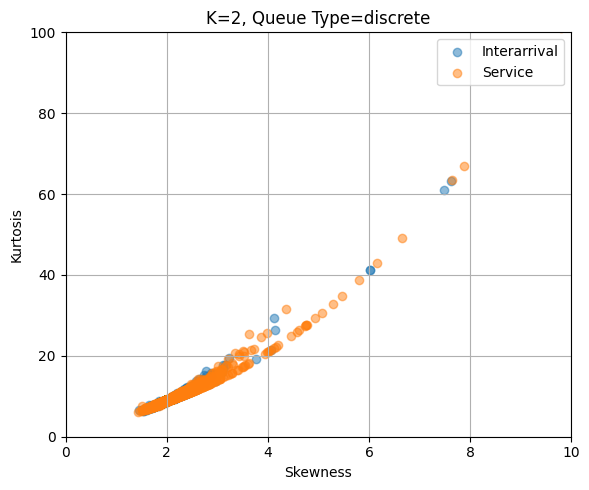

Processing K=2, queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 2 : 101025


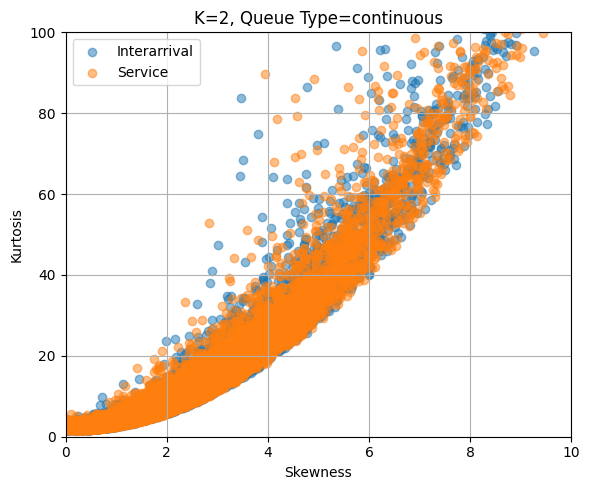

Processing K=3, queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 3 : 42126


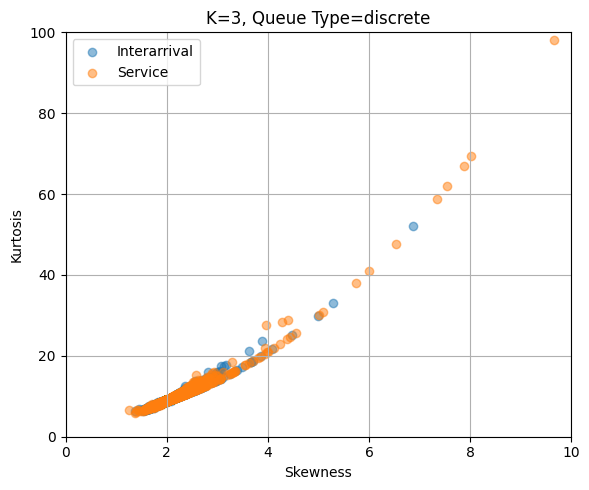

Processing K=3, queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 3 : 68219


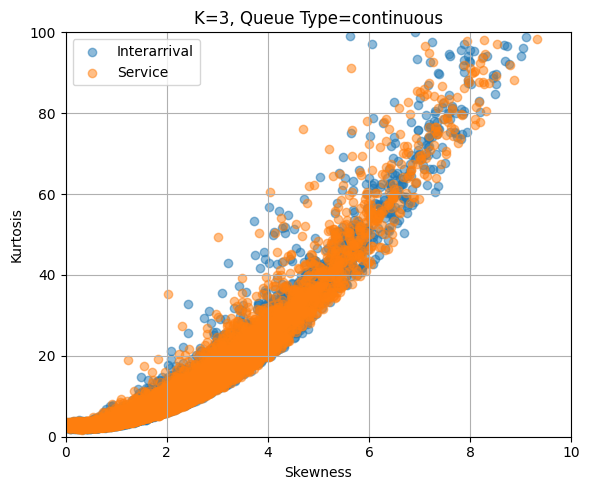

In [16]:
# loop over K and queue_type for all samples
for K in [1,2,3]:
    for queue_type in ['discrete', 'continuous']:
        print(f"Processing K={K}, queue_type={queue_type}")
        plot_skew_kurt(K, queue_type)



In [17]:
# function to plot skew and kurt seperately given K and queue_type
def plot_skew_kurt_seperate(K, queue_type):

    # load samples
    DNN_net = NN_for_Queue(
        queue_type=queue_type, n_max=n_max, Lmax=Lmax, m_max=m_max, input_dim=input_dim, num_classes=Lmax
    )

    df_all_K = DNN_net.Load_and_Merge_All_Samples_for_K(K) 

    # sample shape
    print("Total samples for K=", K, ":", df_all_K.shape[0])

    # Break samples into Moments, stationary distribution, and rho blocks
    Moments_all, Stationary_all, rho_all = Load_Samples_from_file(n_max, Lmax, df_all_K)
    # convert to float
    Moments_all = Moments_all.astype(float)
    Stationary_all = Stationary_all.astype(float)

    Moments_all_real = np.exp(Moments_all) -1 # transfer back to moments
    Moments_arrival = Moments_all_real[:, :n_max] # obtain arrival monents
    Moments_service = Moments_all_real[:, n_max:] # obtain service moments
    # 1. mean normalization
    mom_arr_n = normalize_moments_to_mean_one(Moments_arrival)
    mom_ser_n = normalize_moments_to_mean_one(Moments_service)
    # 2. skewness & kurtosis
    skew_a, kurt_a = skew_kurt_from_raw_moments(mom_arr_n)
    skew_s, kurt_s = skew_kurt_from_raw_moments(mom_ser_n)  
    print(kurt_a)
    print(kurt_s)
    fig, axes = plt.subplots(2, 2, figsize=(8,6), sharex='col')

    # Bin settings
    bins_skew = np.arange(0, 11, 1)     # include 10
    bins_kurt = np.arange(0, 101, 10)   # include 100

    # Arrival skewness
    counts, bin_edges = np.histogram(skew_a, bins=bins_skew)
    probs = counts / counts.sum()

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    axes[0,0].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
    axes[0,0].set_title('Arrival skewness')
    axes[0,0].set_xlim(0, 10)
    axes[0,0].set_ylim(0, 1)
    axes[0,0].set_ylabel('Probability')
    axes[0,0].set_xticks(bin_edges)

    # Arrival kurtosis
    counts, bin_edges = np.histogram(kurt_a, bins=bins_kurt)
    probs = counts / counts.sum()

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    axes[0,1].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
    axes[0,1].set_title('Arrival kurtosis')
    axes[0,1].set_xlim(0, 100)
    axes[0,1].set_ylim(0, 1)
    axes[0,1].set_xticks(bin_edges)

    # Service skewness
    counts, bin_edges = np.histogram(skew_s, bins=bins_skew)
    probs = counts / counts.sum()

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    axes[1,0].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
    axes[1,0].set_title('Service skewness')
    axes[1,0].set_xlim(0, 10)
    axes[1,0].set_ylim(0, 1)
    axes[1,0].set_ylabel('Probability')
    axes[1,0].set_xticks(bin_edges)

    # Service kurtosis
    counts, bin_edges = np.histogram(kurt_s, bins=bins_kurt)
    probs = counts / counts.sum()

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    axes[1,1].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
    axes[1,1].set_title('Service kurtosis')
    axes[1,1].set_xlim(0, 100)
    axes[1,1].set_ylim(0, 1)
    axes[1,1].set_xticks(bin_edges)

    plt.tight_layout()
    plt.show()

Processing K=1, queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 1 : 482270
[ 9.00796836  9.00845169  9.58735865 ... 14.88781885  9.07092962
  8.95813861]
[8.97477027 9.00155008 9.02736556 ... 9.8422844  9.06389668 8.99993283]


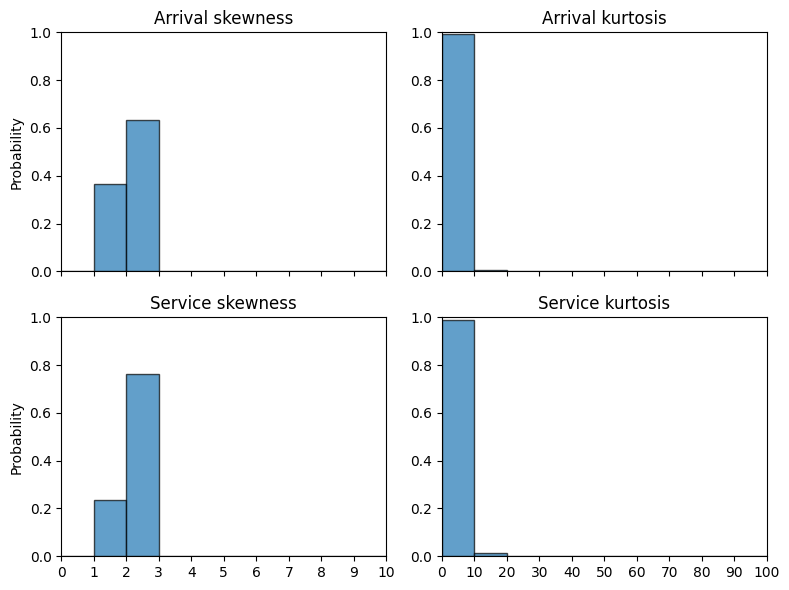

Processing K=1, queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 1 : 530025
[5.         3.5        9.00331234 ... 5.         9.5199278  4.4799792 ]
[15.07195647 17.9327368   3.54545455 ...  6.          9.
  3.46153846]


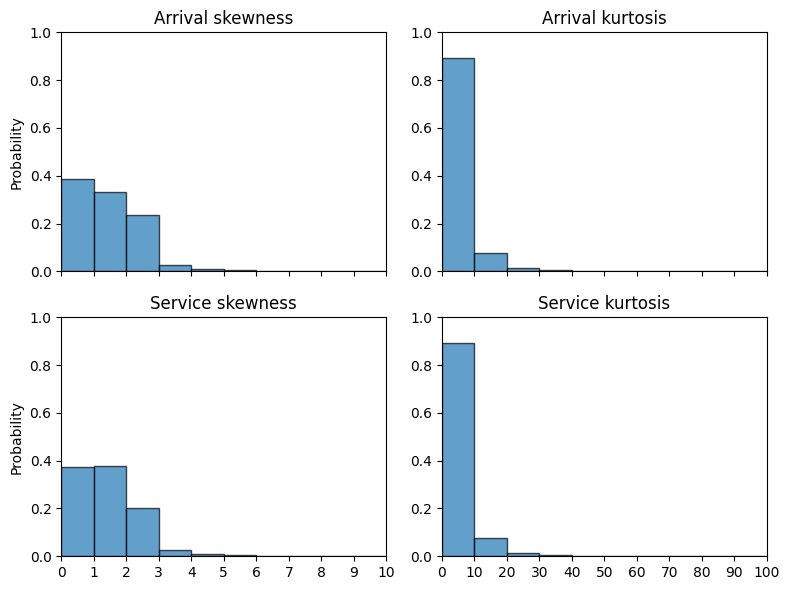

Processing K=2, queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 2 : 89216
[9.00329467 9.01598344 9.26379547 ... 9.36490266 9.00139512 8.99046546]
[9.0266765  8.3975747  8.92366337 ... 9.07313291 9.0044996  8.97697563]


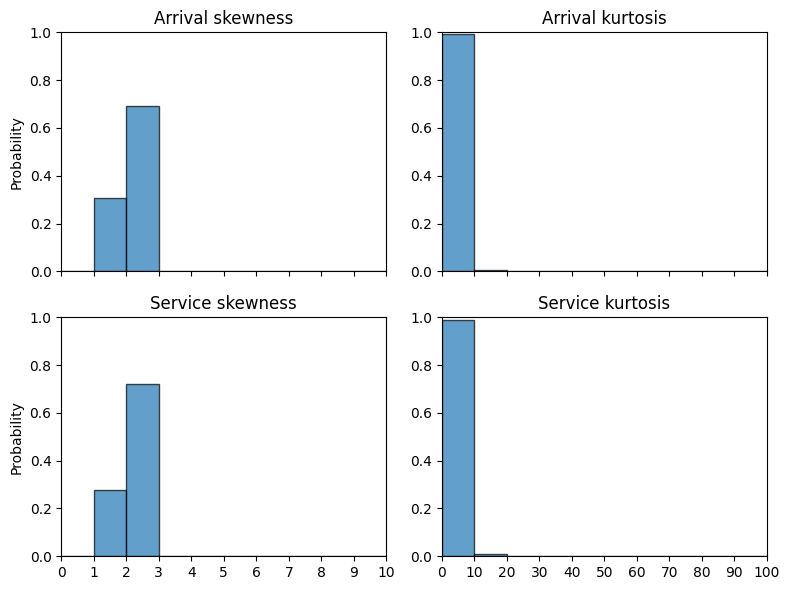

Processing K=2, queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 2 : 101025
[12.43986223  8.99561018  4.11197761 ...  4.5         3.15550748
  3.75      ]
[ 4.          3.4         3.5        ...  8.94169513 16.77557813
  9.03397937]


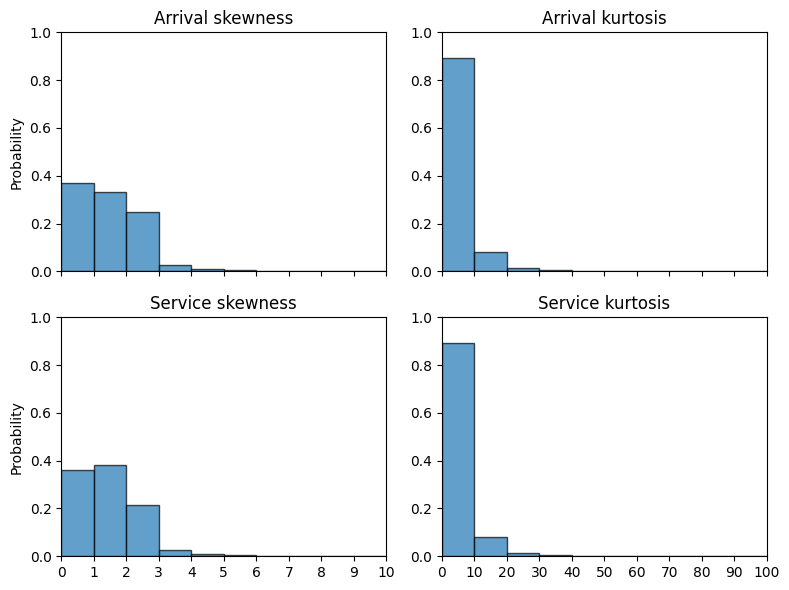

Processing K=3, queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 3 : 42126
[ 8.99847524  9.00156085  9.01491357 ... 10.49057432  9.05114816
  8.9834106 ]
[8.9597818  8.92688378 8.73018854 ... 9.05485588 9.27383762 8.95559352]


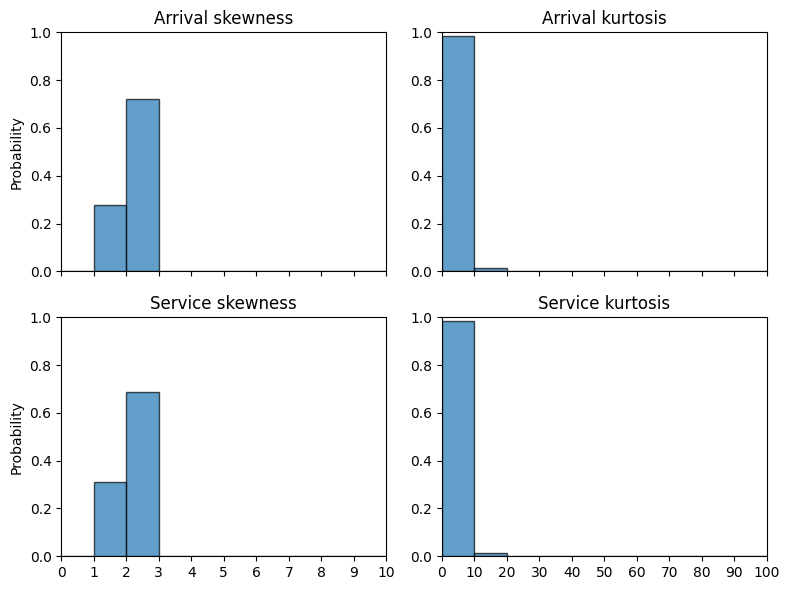

Processing K=3, queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 3 : 68219
[ 4.2         9.         19.96150431 ...  6.43792163  3.6
  5.56873109]
[6.46430165 7.88590678 4.2        ... 9.         8.98607832 4.5       ]


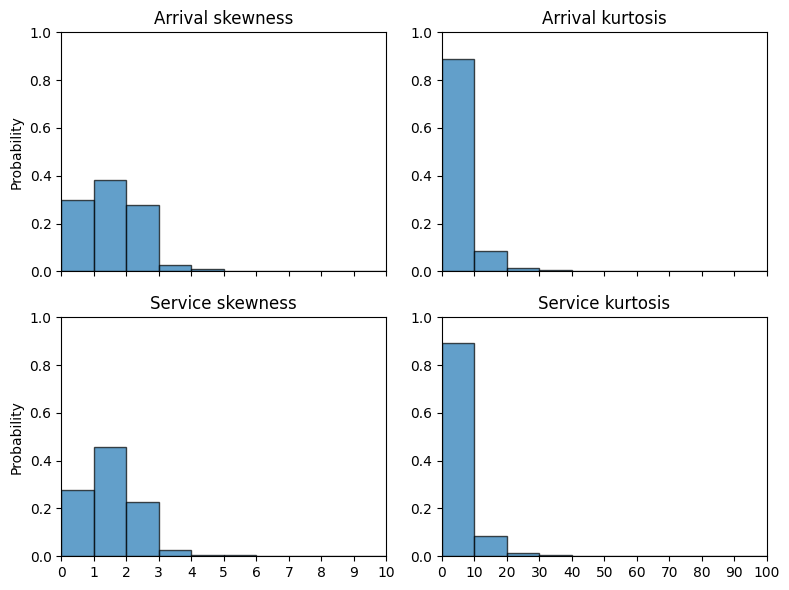

In [18]:
# loop over K and queue_type for all samples
for K in [1,2,3]:
    for queue_type in ['discrete', 'continuous']: 
        print(f"Processing K={K}, queue_type={queue_type}")
        plot_skew_kurt_seperate(K, queue_type)